In [1]:
from stable_baselines3 import PPO, TD3
from sb3_contrib import TQC, RecurrentPPO
from stable_baselines3.common.env_util import make_vec_env
from rl4greencrab import evaluate_agent, multiConstAction, simulator, plot_agent, CentroidAgent
import pandas as pd
import numpy as np
import ray
from skopt import gp_minimize, gbrt_minimize 
from skopt.plots import plot_convergence, plot_objective
from rl4greencrab import TwoActNormalized, twoActEnv
import os
import glob
import re

## Simulate agent actions in the environment

### Constant Action

In [2]:
# read in GP-optimized constant action
x = pd.read_csv("../data/constant_action/constant_actions_result.csv").values[0].tolist()

In [3]:
# create instance of env
config = {
        'random_start': True,
        'var_penalty_const': 0,
        'observation_type': "count-time",
        'control_randomness': True
    }
evalEnv =  twoActEnv(config)

# turn action into agent
constant_agent = multiConstAction(env=evalEnv, action=np.array(x))
const_plot_agent = plot_agent(env_sim_df=None, 
                              agent_name='const_agent', 
                              env=evalEnv, 
                              agent=constant_agent, 
                              save_dir='.')

# run 500 simulations of environment and constant action "agent"                             
df = const_plot_agent.gen_env_sim_df(rep=1, obs_names=['crabs', 'months'])

In [4]:
df.head()

,t,crabs,months,act0,act1,rew,rep,crab_pop,nonlocal_crab
0,0,[0.0],3,1407.20345,420.257129,0.000000,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",[]
1,1,[0.0],3,1407.20345,420.257129,-0.048794,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",[]
2,2,[0.0],4,1407.20345,420.257129,-0.097587,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",[]
3,3,[0.0],5,1407.20345,420.257129,-0.146381,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",[]
4,4,[0.0],6,1407.20345,420.257129,-0.195174,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",[]


In [5]:
boundary = 0+np.arange(0,(22+1),1)*110/22
midpoints = 0.5*(boundary[0:22]+boundary[1:(22+1)])
midpoints

array([  2.5,   7.5,  12.5,  17.5,  22.5,  27.5,  32.5,  37.5,  42.5,
        47.5,  52.5,  57.5,  62.5,  67.5,  72.5,  77.5,  82.5,  87.5,
        92.5,  97.5, 102.5, 107.5])

In [6]:
import matplotlib.pyplot as plt

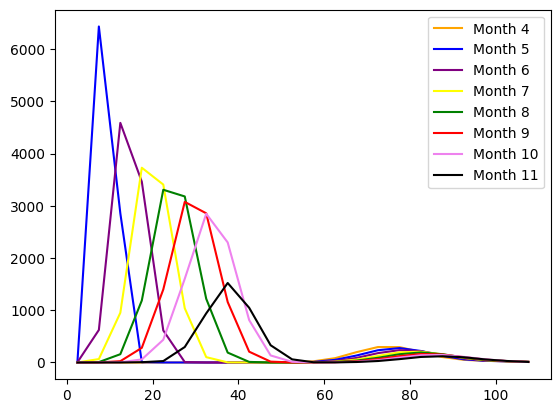

In [10]:
plt.plot(midpoints, df['crab_pop'].iloc[47], color="orange", label=f"Month {df['months'].iloc[47]}")
plt.plot(midpoints, df['crab_pop'].iloc[48], color="blue", label=f"Month {df['months'].iloc[48]}")
plt.plot(midpoints, df['crab_pop'].iloc[49], color="purple", label=f"Month {df['months'].iloc[49]}")
plt.plot(midpoints, df['crab_pop'].iloc[50], color="yellow", label=f"Month {df['months'].iloc[50]}")
plt.plot(midpoints, df['crab_pop'].iloc[51], color="green", label=f"Month {df['months'].iloc[51]}")
plt.plot(midpoints, df['crab_pop'].iloc[52], color="red", label=f"Month {df['months'].iloc[52]}")
plt.plot(midpoints, df['crab_pop'].iloc[53], color="violet", label=f"Month {df['months'].iloc[53]}")
plt.plot(midpoints, df['crab_pop'].iloc[54], color="black", label=f"Month {df['months'].iloc[54]}")
plt.legend()



In [ ]:
# create instance of env
evalEnv =  twoActEnv(config)

# turn action into agent
constant_agent = multiConstAction(env=evalEnv, action=np.array(x))
const_plot_agent = plot_agent(env_sim_df=None, 
                              agent_name='const_agent', 
                              env=evalEnv, 
                              agent=constant_agent, 
                              save_dir='.')

# run 500 simulations of environment and constant action "agent"                             
df = const_plot_agent.gen_env_sim_df(rep=500, obs_names=['crabs'])

# get just final timestep
df_subset = df[df['t'] == 99]

# save df
df_subset.to_csv('../data/const_agent_simulations.csv', index=False)

### RL Policy

##### run ppo simulations

In [ ]:
ppo_files = glob.glob('../saved_agents/**/PPO*.zip', recursive=True)

for filepath in ppo_files:
    parts = filepath.split(os.sep)
    subfolder = parts[2]
    filename = parts[-1]          # e.g., 'PPO-Var0-(count)-2.zip'
    
    obs = filename.split('(')[1].split(')')[0]          # e.g., 'count'
    rep_num = re.search(r'-(\d+)\.zip$', filename).group(1)  # e.g., '2'

    config = {
        'random_start': True,
        'var_penalty_const': 0,
        'observation_type': obs,
        'control_randomness': True
    }
    
    load_path = filepath.replace('.zip', '')
    out_dir = f'../data/rl_policies/{subfolder}'
    save_name = f'ppo_{subfolder}_sim_{rep_num}'        # e.g., 'ppo_count_sim_2'

    print(f"Running simulation for {filepath} -> {out_dir}/{save_name}.csv")

    evalEnv = TwoActNormalized(config)
    ppoAgent = PPO.load(load_path, device="cpu")

    ppo_plot_agent = plot_agent(
        env_sim_df=None,
        agent_name=save_name,
        env=evalEnv,
        agent=ppoAgent,
        save_dir=out_dir
    )
    ppo_plot_agent.save_dir = out_dir  # save directly to data/rl_policies/count/

    ppo_plot_agent.gen_env_sim_df(rep=500, obs_names=['crabs'])
    ppo_plot_agent.save_df(ppo_plot_agent.env_simulation_df, save_name)

print("All simulations complete.")

##### run tqc simulations

In [3]:
config = {
        'random_start': True,
        'var_penalty_const': 0,
        'observation_type': "size-time",
        'control_randomness': True
    }
evalEnv = TwoActNormalized(config)
list(evalEnv.observation_space.spaces.keys())

['crabs', 'months']

In [2]:
tqc_files = glob.glob('../saved_agents/**/TQC*.zip', recursive=True)

for filepath in tqc_files:
    parts = filepath.split(os.sep)
    subfolder = parts[2]
    filename = parts[-1]          # e.g., 'PPO-Var0-(count)-2.zip'
    
    obs = filename.split('(')[1].split(')')[0]          # e.g., 'count'
    rep_num = re.search(r'-(\d+)\.zip$', filename).group(1)  # e.g., '2'

    config = {
        'random_start': True,
        'var_penalty_const': 0,
        'observation_type': obs,
        'control_randomness': True
    }
    
    load_path = filepath.replace('.zip', '')
    out_dir = f'../data/rl_policies/{subfolder}'
    save_name = f'tqc_{subfolder}_sim_{rep_num}'        # e.g., 'ppo_count_sim_2'

    print(f"Running simulation for {filepath} -> {out_dir}/{save_name}.csv")

    evalEnv = TwoActNormalized(config)
    tqcAgent = TQC.load(load_path, device="cpu")

    tqc_plot_agent = plot_agent(
        env_sim_df=None,
        agent_name=save_name,
        env=evalEnv,
        agent=tqcAgent,
        save_dir=out_dir
    )
    tqc_plot_agent.save_dir = out_dir  # save directly to data/rl_policies/count/

    obs_names = list(evalEnv.observation_space.spaces.keys())  # e.g. ['crabs', 'months']


    tqc_plot_agent.gen_env_sim_df(rep=500, obs_names=obs_names)
    tqc_plot_agent.save_df(tqc_plot_agent.env_simulation_df, save_name)

print("All simulations complete.")

Running simulation for ../saved_agents/size-time/TQC-Var0-(size)-2.zip -> ../data/rl_policies/size-time/tqc_size-time_sim_2.csv
Running simulation for ../saved_agents/size-time/TQC-Var0-(size)-5.zip -> ../data/rl_policies/size-time/tqc_size-time_sim_5.csv
Running simulation for ../saved_agents/size-time/TQC-Var0-(size)-4.zip -> ../data/rl_policies/size-time/tqc_size-time_sim_4.csv
Running simulation for ../saved_agents/size-time/TQC-Var0-(size)-3.zip -> ../data/rl_policies/size-time/tqc_size-time_sim_3.csv
Running simulation for ../saved_agents/size-time/TQC-Var0-(size)-1.zip -> ../data/rl_policies/size-time/tqc_size-time_sim_1.csv
Running simulation for ../saved_agents/count-time/TQC-Var0-(count-time)-5.zip -> ../data/rl_policies/count-time/tqc_count-time_sim_5.csv
Running simulation for ../saved_agents/count-time/TQC-Var0-(count-time)-2.zip -> ../data/rl_policies/count-time/tqc_count-time_sim_2.csv
Running simulation for ../saved_agents/count-time/TQC-Var0-(count-time)-3.zip -> ../da

KeyboardInterrupt: 

##### run td3 simulations

In [ ]:
td3_files = glob.glob('../saved_agents/**/TD3*.zip', recursive=True)

for filepath in td3_files:
    parts = filepath.split(os.sep)
    subfolder = parts[2]
    filename = parts[-1]  
    
    obs = filename.split('(')[1].split(')')[0]          # e.g., 'count'
    rep_num = re.search(r'-(\d+)\.zip$', filename).group(1)  # e.g., '2'

    config = {
        'random_start': True,
        'var_penalty_const': 0,
        'observation_type': obs,
        'control_randomness': True
    }
    
    load_path = filepath.replace('.zip', '')
    out_dir = f'../data/rl_policies/{subfolder}'
    save_name = f'td3_{subfolder}_sim_{rep_num}'     

    print(f"Running simulation for {filepath} -> {out_dir}/{save_name}.csv")

    evalEnv = TwoActNormalized(config)
    td3Agent = TD3.load(load_path, device="cpu")

    td3_plot_agent = plot_agent(
        env_sim_df=None,
        agent_name=save_name,
        env=evalEnv,
        agent=td3Agent,
        save_dir=out_dir
    )
    td3_plot_agent.save_dir = out_dir  # save directly to data/rl_policies/count/

    td3_plot_agent.gen_env_sim_df(rep=500, obs_names=['crabs'])
    td3_plot_agent.save_df(td3_plot_agent.env_simulation_df, save_name)

print("All simulations complete.")

In [20]:
df_td3_sub = df_td3[df_td3['t'] == 99]
df_ppo_sub = df[df['t'] == 99]
df_tqc_sub = df_tqc[df_tqc['t'] == 99]

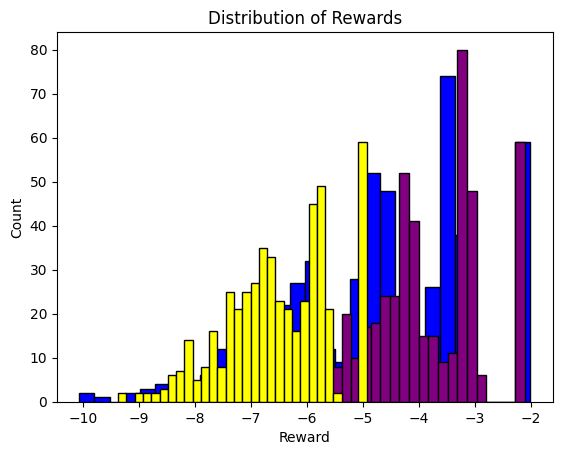

In [22]:
import matplotlib.pyplot as plt

plt.hist(df_td3_sub['rew'], bins=30, edgecolor='black', color = 'blue')
plt.hist(df_ppo_sub['rew'], bins=30, edgecolor='black', color = 'purple')
plt.hist(df_tqc_sub['rew'], bins=30, edgecolor='black', color = 'yellow')
plt.xlabel('Reward')
plt.ylabel('Count')
plt.title('Distribution of Rewards')
plt.show()

### Clustered Policy

In [4]:
centroids = pd.read_csv("../clustering/centroids.csv")

evalEnv = TwoActNormalized(config)
centroid_agent = CentroidAgent(centroids=centroids, env=evalEnv)
centroid_plot_agent = plot_agent(env_sim_df=None,
                                 agent_name='centroid_agent',
                                 env=evalEnv,
                                 agent=centroid_agent,
                                 save_dir='.')
df = centroid_plot_agent.gen_env_sim_df(rep=500, obs_names=['crabs'])
#ppo_plot_agent.save_df(ppo_plot_agent.env_simulation_df, 'ppo_size_sim_500')

In [16]:
# get just final timestep
df_subset = df[df['t'] == 99]
df_subset.head()

,t,crabs,act0,act1,rew,rep,crab_pop,nonlocal_crab
99,99,"[-0.91897255, -0.80429494]",-0.964028,-0.631714,-7.667932,0,"[11179.273985279708, 5342.582057112939, 1.2304...","[84739.36435937966, 0.0, 82609.14807922786, 0...."
199,99,"[-0.9740107, -0.7531064]",-0.964028,0.227240,-5.982570,1,"[6461.446879197006, 3087.9295207579266, 0.7111...","[84739.36435937966, 0.0, 82609.14807922786, 0...."
299,99,"[-0.9711637, -0.7483277]",-0.964028,0.227240,-7.806545,2,"[7350.349811188674, 3512.7367901053863, 0.8090...","[84739.36435937966, 0.0, 82609.14807922786, 0...."
399,99,"[-0.9702689, -0.7575864]",-0.964028,0.227240,-4.456956,3,"[7387.2613829012325, 3530.3768534038636, 0.813...","[84739.36435937966, 0.0, 82609.14807922786, 0...."
499,99,"[-0.97018754, -0.73625493]",-0.964028,0.607146,-4.144993,4,"[7344.175170686521, 3509.7859255323056, 0.8083...","[84739.36435937966, 0.0, 82609.14807922786, 0...."


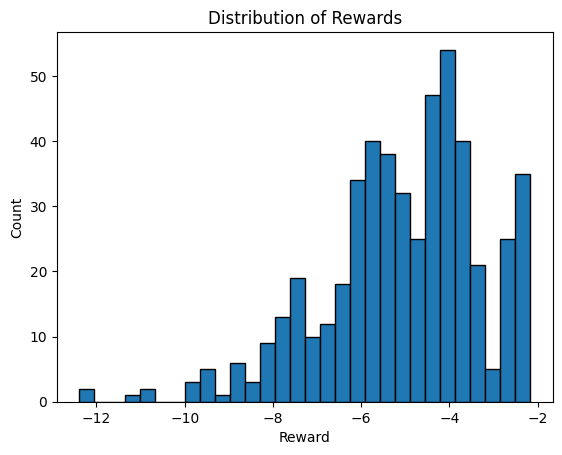

In [20]:
import matplotlib.pyplot as plt

plt.hist(df_subset['rew'], bins=30, edgecolor='black')
plt.xlabel('Reward')
plt.ylabel('Count')
plt.title('Distribution of Rewards')
plt.show()


In [22]:
df_subset['rew'].mean()


np.float64(-5.057694885022637)